# Phase 0 — Foundations of Machine Learning

Before writing a single line of ML code, you need to understand **what ML actually is**, how it differs from traditional programming, and what types of problems it solves.

## What You Will Learn

| Topic | What you will understand |
|---|---|
| What is ML? | How machines learn from data |
| AI vs ML vs Deep Learning | The hierarchy and differences |
| Types of ML | Supervised, Unsupervised, Reinforcement |
| Core ML Concepts | Features (X), Target (y), training, testing, prediction |
| Where sklearn fits | Its role in the ML workflow |
| Real-world applications | Where ML is used today |

## 1 — What is Machine Learning?

### Traditional Programming vs Machine Learning

**Traditional Programming:**
```
Rules + Data → Answers
```
You write explicit if-else rules. The computer follows your exact instructions.

**Machine Learning:**
```
Data + Answers → Rules (learned automatically)
```
You feed examples. The algorithm discovers the rules itself.

### Simple Definition
> Machine Learning is the science of getting computers to **learn from experience** (data) and **improve at tasks** without being explicitly programmed for each task.

### Why ML Instead of Traditional Code?

| Problem | Traditional Code | Machine Learning |
|---|---|---|
| Detect spam email | Write rules for every spam word | Train on millions of emails, learns patterns |
| Recognise a cat | Write rules for ears, fur, whiskers... | Show 100,000 cat photos, it learns |
| Predict house price | Write a formula manually | Train on past sales data, learns relationship |

When rules are **too complex to write manually**, ML learns them automatically.

In [1]:
# ── Traditional Programming vs Machine Learning (side by side) ────────────────

print('=' * 60)
print('APPROACH 1: Traditional Rule-Based Code')
print('=' * 60)

def traditional_pass_fail(study_hours, attendance):
    """Manually written rules — developer decides the thresholds."""
    if study_hours >= 6 and attendance >= 75:
        return 'Pass'
    elif study_hours >= 8:
        return 'Pass'
    elif attendance >= 90:
        return 'Pass'
    else:
        return 'Fail'

test_students = [(7, 80), (3, 50), (5, 90), (9, 40), (4, 70)]
print(f'{"Study Hours":<14} {"Attendance":<12} {"Result"}')
for sh, att in test_students:
    print(f'{sh:<14} {att:<12} {traditional_pass_fail(sh, att)}')

print('\nProblem: rules are guesswork. What if the real threshold is 5.5 hours, not 6?')
print('         Adding more features (past score, sleep, internet) → rules explode!')

print('\n' + '=' * 60)
print('APPROACH 2: Machine Learning — learns the rules from data')
print('=' * 60)

import numpy as np
from sklearn.tree import DecisionTreeClassifier, export_text

np.random.seed(42)
n = 200
study  = np.random.uniform(1, 10, n)
attend = np.random.uniform(40, 100, n)
# The "true" rule we want the model to discover:
passed = ((study * 4 + attend * 0.3 + np.random.normal(0, 6, n)) > 50).astype(int)

X = np.column_stack([study, attend])

model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X, passed)  # ← model DISCOVERS the rules from the data

print('\nRules learned BY THE MODEL (without you writing any if-else):')
rules = export_text(model, feature_names=['StudyHours', 'Attendance'])
print(rules)

print('\nPredictions on the same test students:')
for sh, att in test_students:
    pred = model.predict([[sh, att]])[0]
    prob = model.predict_proba([[sh, att]])[0][1]
    print(f'  Study={sh}, Attend={att}  → {"Pass" if pred==1 else "Fail"}  (confidence: {prob:.0%})')

APPROACH 1: Traditional Rule-Based Code
Study Hours    Attendance   Result
7              80           Pass
3              50           Fail
5              90           Pass
9              40           Pass
4              70           Fail

Problem: rules are guesswork. What if the real threshold is 5.5 hours, not 6?
         Adding more features (past score, sleep, internet) → rules explode!

APPROACH 2: Machine Learning — learns the rules from data

Rules learned BY THE MODEL (without you writing any if-else):
|--- StudyHours <= 5.90
|   |--- StudyHours <= 5.67
|   |   |--- Attendance <= 92.33
|   |   |   |--- class: 0
|   |   |--- Attendance >  92.33
|   |   |   |--- class: 0
|   |--- StudyHours >  5.67
|   |   |--- StudyHours <= 5.71
|   |   |   |--- class: 1
|   |   |--- StudyHours >  5.71
|   |   |   |--- class: 0
|--- StudyHours >  5.90
|   |--- Attendance <= 55.78
|   |   |--- Attendance <= 44.25
|   |   |   |--- class: 0
|   |   |--- Attendance >  44.25
|   |   |   |--- class:

## 2 — AI vs Machine Learning vs Deep Learning

These three terms are often confused. They are nested concepts:

```
┌─────────────────────────────────────────────────────┐
│                 Artificial Intelligence              │
│    (any technique that makes machines seem smart)    │
│                                                      │
│    ┌──────────────────────────────────────────┐     │
│    │           Machine Learning                │     │
│    │  (learns patterns from data/experience)   │     │
│    │                                           │     │
│    │    ┌───────────────────────────────┐     │     │
│    │    │        Deep Learning          │     │     │
│    │    │  (multi-layer neural networks │     │     │
│    │    │   learns from massive data)   │     │     │
│    │    └───────────────────────────────┘     │     │
│    └──────────────────────────────────────────┘     │
└─────────────────────────────────────────────────────┘
```

| | AI | ML | Deep Learning |
|---|---|---|---|
| **Definition** | Machines mimicking human intelligence | Subset of AI: learns from data | Subset of ML: multi-layer neural nets |
| **Examples** | Chess engine, GPS navigation | Email spam filter, house price prediction | Image recognition, ChatGPT, voice assistants |
| **Data needed** | Varies | Hundreds to thousands of rows | Millions of examples |
| **Hardware** | CPU | CPU | GPU (graphics cards) |
| **Interpretability** | Often explainable | Usually interpretable | Black box (hard to explain) |
| **Tool (Python)** | Any library | **scikit-learn** | TensorFlow, PyTorch |

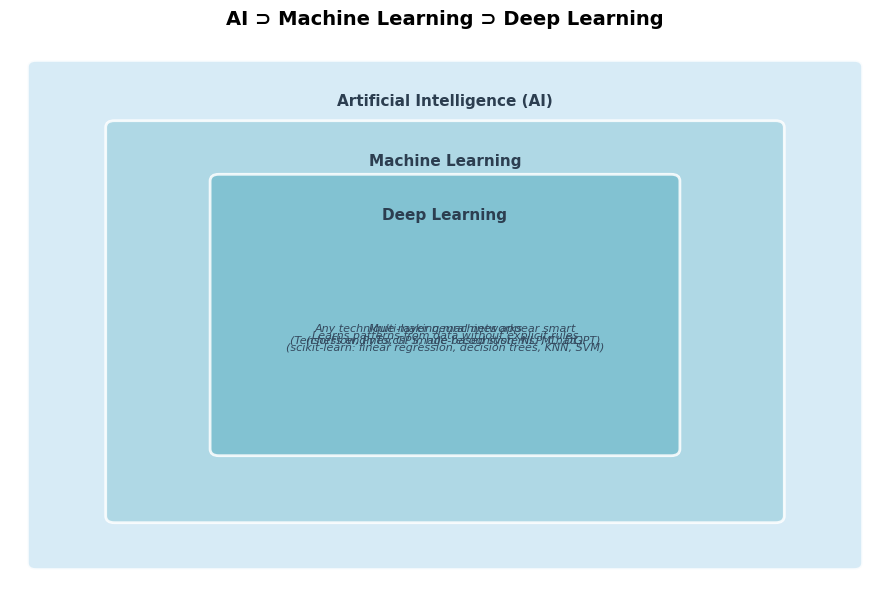

Key takeaway:
  All Deep Learning is ML, but not all ML is Deep Learning
  All ML is AI, but not all AI is ML
  scikit-learn = Machine Learning (not Deep Learning)
  When to use sklearn vs deep learning:
    sklearn  → structured/tabular data, small-medium datasets, fast training
    DL       → images, audio, text, very large datasets, raw unstructured data


In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(9, 6))
ax.set_xlim(0, 10); ax.set_ylim(0, 8); ax.axis('off')
fig.suptitle('AI ⊃ Machine Learning ⊃ Deep Learning', fontsize=14, fontweight='bold')

# Draw concentric rectangles
for (x, y, w, h, color, label, sublabel) in [
    (0.3, 0.3, 9.4, 7.4, '#d0e8f5', 'Artificial Intelligence (AI)',
     'Any technique making machines appear smart\n(chess engines, GPS, rule-based systems, ML, DL)'),
    (1.2, 1.0, 7.6, 5.8, '#a8d5e2', 'Machine Learning',
     'Learns patterns from data without explicit rules\n(scikit-learn: linear regression, decision trees, KNN, SVM)'),
    (2.4, 2.0, 5.2, 4.0, '#7abfcf', 'Deep Learning',
     'Multi-layer neural networks\n(TensorFlow, PyTorch: image recognition, NLP, ChatGPT)'),
]:
    rect = mpatches.FancyBboxPatch((x, y), w, h,
                                    boxstyle='round,pad=0.1',
                                    linewidth=2, edgecolor='white',
                                    facecolor=color, alpha=0.85)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h - 0.4, label, ha='center', va='top',
            fontsize=11, fontweight='bold', color='#2c3e50')
    ax.text(x + w/2, y + h/2 - 0.3, sublabel, ha='center', va='center',
            fontsize=8, color='#34495e', style='italic')

plt.tight_layout()
plt.show()

print('Key takeaway:')
print('  All Deep Learning is ML, but not all ML is Deep Learning')
print('  All ML is AI, but not all AI is ML')
print('  scikit-learn = Machine Learning (not Deep Learning)')
print('  When to use sklearn vs deep learning:')
print('    sklearn  → structured/tabular data, small-medium datasets, fast training')
print('    DL       → images, audio, text, very large datasets, raw unstructured data')

## 3 — Types of Machine Learning

### Supervised Learning
Training data has **labels** — the correct answer is provided for every example.
The model learns the mapping from inputs → outputs.

- **Regression** → predict a **number** (house price, exam score, temperature)
- **Classification** → predict a **category** (Pass/Fail, spam/not-spam, dog/cat)

### Unsupervised Learning
Training data has **no labels** — the model discovers hidden structure on its own.

- **Clustering** → group similar items together (customer segments, topic grouping)
- **Dimensionality Reduction** → compress many features into fewer (PCA)

### Reinforcement Learning
An **agent** learns by trial and error — takes actions, receives rewards or penalties, improves strategy over time.
- Games (AlphaGo, Chess AI), Robotics, Self-driving cars, Trading bots

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.cluster import KMeans

np.random.seed(42)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Three Types of Machine Learning', fontsize=13, fontweight='bold')

# ─── SUPERVISED: REGRESSION ──────────────────────────────────────────────────
# Labels provided: we know the exact score for each study hour
hours  = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10]).reshape(-1, 1)
scores = np.array([35, 45, 52, 58, 65, 72, 78, 84, 89, 95])

reg = LinearRegression().fit(hours, scores)
hour_range = np.linspace(0, 11, 100).reshape(-1, 1)
pred_line  = reg.predict(hour_range)

axes[0].scatter(hours, scores, color='steelblue', s=80, zorder=5, label='Training data (labelled)')
axes[0].plot(hour_range, pred_line, 'r-', lw=2, label='Learned line')
axes[0].scatter([11], reg.predict([[11]]), color='gold', s=150, marker='*',
                zorder=6, label=f'New prediction: {reg.predict([[11]])[0]:.0f}')
axes[0].set_title('Supervised — Regression\n(predict score from hours studied)')
axes[0].set_xlabel('Study Hours'); axes[0].set_ylabel('Exam Score')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

# ─── SUPERVISED: CLASSIFICATION ──────────────────────────────────────────────
hours_c = np.random.uniform(1, 10, 60).reshape(-1, 1)
passed_c = (hours_c.ravel() + np.random.normal(0, 1.5, 60) > 5.5).astype(int)

clf = LogisticRegression(max_iter=500).fit(hours_c, passed_c)
h_range = np.linspace(0, 11, 200).reshape(-1, 1)
prob    = clf.predict_proba(h_range)[:, 1]

axes[1].scatter(hours_c[passed_c==0], passed_c[passed_c==0],
                color='tomato', s=40, alpha=0.7, label='Fail (label=0)')
axes[1].scatter(hours_c[passed_c==1], passed_c[passed_c==1],
                color='mediumseagreen', s=40, alpha=0.7, label='Pass (label=1)')
axes[1].plot(h_range, prob, 'steelblue', lw=2.5, label='P(Pass) — sigmoid curve')
axes[1].axhline(0.5, color='gray', linestyle='--', lw=1.5, label='Decision boundary')
axes[1].set_title('Supervised — Classification\n(predict Pass or Fail from hours)')
axes[1].set_xlabel('Study Hours'); axes[1].set_ylabel('P(Pass)')
axes[1].legend(fontsize=7); axes[1].grid(True, alpha=0.3)

# ─── UNSUPERVISED: CLUSTERING ────────────────────────────────────────────────
# NO labels — model discovers groups on its own
age      = np.concatenate([np.random.normal(25,4,30), np.random.normal(45,4,35), np.random.normal(65,4,25)])
spending = np.concatenate([np.random.normal(75,8,30), np.random.normal(50,8,35), np.random.normal(28,6,25)])
X_clust  = np.column_stack([age, spending])

from sklearn.preprocessing import StandardScaler
km = KMeans(n_clusters=3, random_state=42, n_init=10).fit(StandardScaler().fit_transform(X_clust))
labels = km.labels_

colors = ['tomato', 'steelblue', 'mediumseagreen']
for cluster_id in range(3):
    mask = labels == cluster_id
    axes[2].scatter(X_clust[mask, 0], X_clust[mask, 1],
                    color=colors[cluster_id], s=50, alpha=0.7, label=f'Group {cluster_id+1}')
axes[2].set_title('Unsupervised — Clustering\n(no labels — model finds 3 groups)')
axes[2].set_xlabel('Age'); axes[2].set_ylabel('Spending Score')
axes[2].legend(title='Discovered Groups', fontsize=8); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('Summary:')
print('  Supervised   → has labels  → use when you have X and y pairs')
print('  Unsupervised → no labels   → use when you only have X (find hidden patterns)')
print('  Reinforcement→ learns from reward/penalty → games, robots, auto trading')

## 4 — Core ML Concepts: X, y, Training, Testing, Prediction

### Features (X) and Target (y)

```
Dataset row:  [StudyHours=6, Attendance=85, PastScore=72]  →  Passed=Yes
               ──────────────────────────────────────────      ──────────
                           Features  (X)                       Target (y)
```

- **X** (features / inputs) — everything the model uses to make a prediction
- **y** (target / label / output) — what the model tries to predict

### Train → Test → Predict

```
All Data
   │
   ├─ Training Set (80%) ─→ model.fit(X_train, y_train)   ← model LEARNS here
   │
   └─ Test Set     (20%) ─→ model.predict(X_test)         ← evaluate honestly here
                                   │
                                   └─→ New Data ─→ model.predict(new_data)  ← deployment
```

**Why split?** If you test on data the model trained on, it will look artificially good — like giving students the exact questions before the exam. The test set simulates real-world unseen data.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

np.random.seed(42)

# ── DATASET: features (X) and target (y) ─────────────────────────────────────
df = pd.DataFrame({
    'StudyHours': [6, 3, 8, 2, 7, 5, 9, 1, 6, 4, 8, 3, 7, 2, 5],
    'Attendance': [85, 55, 92, 45, 88, 70, 95, 40, 80, 60, 90, 50, 82, 48, 75],
    'PastScore':  [72, 45, 88, 38, 82, 60, 91, 32, 70, 52, 86, 42, 78, 36, 64],
    'Passed':     [1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1,  0,  1],
})

print('=== Full Dataset ===')
print(df.to_string(index=False))
print(f'\nRows: {df.shape[0]}  |  Columns: {df.shape[1]}')

# ── SEPARATE X AND y ─────────────────────────────────────────────────────────
X = df[['StudyHours', 'Attendance', 'PastScore']]   # features — 2D (n_samples, n_features)
y = df['Passed']                                     # target   — 1D (n_samples,)

print(f'\nX (features) shape: {X.shape}  → every row is one student\'s inputs')
print(f'y (target)   shape: {y.shape}  → every value is the correct answer')
print(f'\nClass balance: {(y==1).sum()} Pass, {(y==0).sum()} Fail')

# ── TRAIN / TEST SPLIT ────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% goes to test set
    random_state=42,    # fixed seed → same split every run → reproducible results
    shuffle=True,       # randomly mix before splitting (default)
)

print(f'\n=== Train / Test Split ===')
print(f'Total  : {len(X)} samples')
print(f'Train  : {len(X_train)} samples ({len(X_train)/len(X)*100:.0f}%)  ← model sees this')
print(f'Test   : {len(X_test)} samples  ({len(X_test)/len(X)*100:.0f}%)  ← held out, never seen during training')
print(f'\nTraining data (what the model learns from):')
print(X_train.head())

# ── TRAIN THE MODEL ───────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train_s, y_train)   # ← model LEARNS from training data
print('\nModel training complete.')

# ── EVALUATE ON TEST SET ──────────────────────────────────────────────────────
y_pred = model.predict(X_test_s)  # predict on UNSEEN test data
acc    = accuracy_score(y_test, y_pred)

print(f'\n=== Honest Evaluation (on test set — data model never saw) ===')
result_df = pd.DataFrame({
    'Actual':    y_test.values,
    'Predicted': y_pred,
    'Correct':   y_test.values == y_pred
})
print(result_df.to_string(index=False))
print(f'\nAccuracy on test set: {acc:.2%}')

# ── PREDICT ON COMPLETELY NEW DATA ───────────────────────────────────────────
print('\n=== Predict New Students (never in dataset at all) ===')
new_students = pd.DataFrame([
    {'StudyHours': 7, 'Attendance': 88, 'PastScore': 78},   # looks like a passer
    {'StudyHours': 2, 'Attendance': 50, 'PastScore': 40},   # looks like a failer
])
new_scaled = scaler.transform(new_students)   # same scaler, do NOT re-fit
new_preds  = model.predict(new_scaled)
new_probs  = model.predict_proba(new_scaled)[:, 1]

for i, (pred, prob) in enumerate(zip(new_preds, new_probs)):
    print(f'  New Student {i+1}: Predicted={"Pass" if pred==1 else "Fail"}  Confidence={prob:.0%}')

## 5 — Where Scikit-learn Fits in the ML Workflow

```
Raw Data (CSV / Database / API)
         │
         ▼
  ┌─────────────────┐
  │   PANDAS        │  → load, explore, clean, encode, split X and y
  └────────┬────────┘
           │
           ▼
  ┌─────────────────┐
  │   SCIKIT-LEARN  │  → preprocess (scale/encode) + train + evaluate + tune
  │                 │
  │   Preprocessing │  SimpleImputer, StandardScaler, LabelEncoder, OneHotEncoder
  │   Supervised    │  LinearRegression, LogisticRegression, DecisionTree, KNN, SVM
  │   Unsupervised  │  KMeans, PCA, DBSCAN
  │   Evaluation    │  accuracy_score, r2_score, confusion_matrix, cross_val_score
  │   Tuning        │  GridSearchCV, RandomizedSearchCV, Pipeline
  └────────┬────────┘
           │
           ▼
  ┌─────────────────┐
  │  DEPLOY / USE   │  → joblib.dump(model) → joblib.load → model.predict(new_data)
  └─────────────────┘
```

### Why Scikit-learn?
- **Consistent API** — every model uses the same `.fit()` / `.predict()` / `.transform()` pattern
- **Battle-tested** — used in production at thousands of companies
- **Documentation** — best docs of any ML library
- **Fast to prototype** — go from idea to trained model in 5 lines

In [ ]:
# ── SKLEARN'S UNIVERSAL API ───────────────────────────────────────────────────
# Every sklearn estimator follows the SAME pattern:
#   1. Create model object (no learning yet)
#   2. model.fit(X_train, y_train)    ← LEARN (transformers also accept just X)
#   3. model.predict(X_new)           ← PREDICT (estimators)
#      model.transform(X_new)         ← TRANSFORM (preprocessors)

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
import numpy as np

np.random.seed(42)

# Sample data
X_demo = np.array([[6,85],[3,55],[8,92],[2,45],[7,88],[5,70],[9,95],[4,60]])
y_demo = np.array([1, 0, 1, 0, 1, 0, 1, 0])  # Pass/Fail
y_reg  = np.array([75, 45, 90, 35, 82, 58, 92, 50])  # Scores

# Scale first
scaler = StandardScaler()
X_s = scaler.fit_transform(X_demo)

print('=== Scikit-learn Universal API — same .fit() / .predict() pattern everywhere ===')

models = [
    ('LinearRegression',       LinearRegression(),                 y_reg,  'predict (number)'),
    ('LogisticRegression',     LogisticRegression(max_iter=500),   y_demo, 'predict (class)'),
    ('DecisionTree',           DecisionTreeClassifier(max_depth=2),y_demo, 'predict (class)'),
    ('KNN (n_neighbors=3)',    KNeighborsClassifier(n_neighbors=3),y_demo, 'predict (class)'),
]

for name, model, y_target, predict_type in models:
    model.fit(X_s, y_target)                       # SAME .fit() for all
    pred = model.predict(X_s[:2])                  # SAME .predict() for all
    print(f'  {name:<28} .fit() → .predict() → {pred}   ({predict_type})')

print()
print('Transformers use .fit_transform() / .transform():')
print(f'  StandardScaler   .fit_transform(X) → scaled features')
print(f'  PCA              .fit_transform(X) → compressed features')
print(f'  SimpleImputer    .fit_transform(X) → imputed features')

print()
print('=== Why This Matters ===')
print('  Switching from Logistic Regression to Decision Tree = change ONE line:')
print('  model = LogisticRegression()     →     model = DecisionTreeClassifier()')
print('  Everything else (fit, predict, evaluate) stays identical.')

## 6 — Real-World ML Applications

Practically every tech product you use runs on ML. Here are common examples broken into the ML components:

| Application | X (Features / Inputs) | y (Target / Output) | ML Type |
|---|---|---|---|
| Email spam filter | Word frequencies, sender, links | Spam / Not Spam | Classification |
| House price prediction | Size, location, bedrooms, age | Price (₹) | Regression |
| Netflix recommendations | Watch history, ratings, genre | "You might like..." | Clustering / Collaborative Filtering |
| Medical diagnosis | Symptoms, test results, age | Disease / No Disease | Classification |
| Credit score | Income, debt, payment history | Risk score | Regression |
| Face recognition | Pixel values of image | Person's identity | Classification (DL) |
| Weather forecast | Temperature, humidity, pressure | Tomorrow's weather | Regression |
| Customer segmentation | Purchase history, age, location | Customer group | Clustering |

**Assignment**: Pick any 3 from the table above. For each, write out:
- What would the full dataset look like? (What columns?)
- What is X? What is y?
- Is it regression or classification?

In [ ]:
import pandas as pd
import numpy as np

# ── REAL-WORLD EXAMPLE 1: House Price Prediction ─────────────────────────────
print('=== Example 1: House Price Prediction (Regression) ===')
houses = pd.DataFrame({
    'SizeSqFt':   [800, 1200, 1500, 2000, 900, 1800, 2500],   # feature
    'Bedrooms':   [2,   3,    3,    4,    2,   4,    5   ],    # feature
    'AgeYears':   [5,   10,   3,    15,   8,   2,    20  ],    # feature
    'Price_Lakh': [45,  72,   85,   115,  52,  98,   130 ],    # TARGET (y)
})
print(houses.to_string(index=False))
print(f'X = [SizeSqFt, Bedrooms, AgeYears]  →  y = Price_Lakh')
print(f'Type: REGRESSION — predicting a number (price in lakhs)')

print()

# ── REAL-WORLD EXAMPLE 2: Email Spam Filter ──────────────────────────────────
print('=== Example 2: Email Spam Detection (Classification) ===')
emails = pd.DataFrame({
    'Contains_Winner': [1, 0, 1, 0, 1, 0],     # feature: keyword
    'Contains_Offer':  [1, 0, 0, 0, 1, 0],     # feature: keyword
    'NumLinks':        [5, 1, 8, 2, 6, 1],     # feature: link count
    'SenderKnown':     [0, 1, 0, 1, 0, 1],     # feature: is sender in contacts?
    'IsSpam':          [1, 0, 1, 0, 1, 0],     # TARGET (y)
})
print(emails.to_string(index=False))
print(f'X = [Contains_Winner, Contains_Offer, NumLinks, SenderKnown]  →  y = IsSpam')
print(f'Type: CLASSIFICATION — predicting a category (Spam=1 or Not=0)')

print()

# ── REAL-WORLD EXAMPLE 3: Customer Segmentation ──────────────────────────────
print('=== Example 3: Customer Segmentation (Unsupervised Clustering) ===')
customers = pd.DataFrame({
    'Age':               [23, 45, 67, 31, 52, 28, 60],
    'MonthlySpend_INR':  [8000, 5000, 2500, 9500, 4000, 7000, 3000],
    'OrdersPerMonth':    [8, 4, 2, 10, 3, 7, 2],
})
print(customers.to_string(index=False))
print(f'X = [Age, MonthlySpend, OrdersPerMonth]  →  y = None (no labels!)')
print(f'Type: CLUSTERING (Unsupervised) — algorithm discovers groups itself')
print(f'Output: Group 0 (young high spenders), Group 1 (middle moderate), Group 2 (senior low)')

## Phase 0 Summary

```
What is ML?
  Traditional code: Rules + Data → Output
  Machine Learning: Data + Output → Rules  (learned automatically from examples)

AI ⊃ Machine Learning ⊃ Deep Learning
  sklearn = Machine Learning (structured/tabular data, small-medium size)
  TensorFlow/PyTorch = Deep Learning (images, audio, text, huge datasets)

Types of ML:
  Supervised    → has labels (X and y) → regression (number) or classification (category)
  Unsupervised  → no labels (only X)   → clustering (KMeans) or compression (PCA)
  Reinforcement → agent + reward       → games, robots, trading

Core Concepts:
  X = feature matrix    shape (n_samples, n_features)   ← inputs
  y = target vector     shape (n_samples,)               ← what we predict
  Training set  → model.fit(X_train, y_train)            ← model learns here
  Test set      → model.predict(X_test)                  ← honest evaluation
  New data      → model.predict(X_new)                   ← real-world use

Scikit-learn API (same for ALL models):
  model = SomeModel()              # 1. Create
  model.fit(X_train, y_train)      # 2. Train
  model.predict(X_test)            # 3. Predict
  model.score(X_test, y_test)      # 4. Evaluate

Next → Phase 1: Python + NumPy + Pandas for ML
```